# 03 Open Bandit known-propensity recommendation designs

This notebook uses Open Bandit as the known-propensity recommendation and support-stress anchor. It keeps the campaign fixed at `men` and compares two logging policies: `random/men`, a uniform exploration slice with constant propensities, and `bts/men`, an adaptive bandit slice with heterogeneous propensities. The design-risk and frontier figures use `bts/men` as the more realistic propensity-stress case, while the random slice remains a clean baseline for known-propensity validation.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "online_experiment_designs_under_interference" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "src"))

from config import ProjectPaths
from data_cases import (
    load_open_bandit_sample,
    open_bandit_calibration,
    open_bandit_propensity_diagnostics,
    run_open_bandit_known_propensity_case,
)
from designs import design_recommendations, pareto_frontier, uncertainty_shortlist
from figures import (
    plot_bias_variance_frontier,
    plot_design_risk,
    plot_open_bandit_propensity_comparison,
)
from progress import ProgressLogger
from tables import write_table

paths = ProjectPaths.from_anywhere(PROJECT_ROOT)
paths.ensure()
progress = ProgressLogger("03-open-bandit")


In [2]:
progress.log("Loading full Open Bandit random/men and equal-count bts/men samples with logged propensities.")
open_bandit_path = paths.data_dir / "open_bandit" / "open_bandit_dataset.zip"
random_case = {"behavior_policy": "random", "campaign": "men", "nrows": None}
random_sample = load_open_bandit_sample(open_bandit_path, **random_case)
target_nrows = len(random_sample)
open_bandit_cases = [
    {**random_case, "requested_nrows": "full", "analysis_rows": target_nrows},
    {"behavior_policy": "bts", "campaign": "men", "nrows": target_nrows, "requested_nrows": target_nrows, "analysis_rows": target_nrows},
]

samples = {"random_men": random_sample}
calibration_rows = []
for case in open_bandit_cases:
    key = f"{case['behavior_policy']}_{case['campaign']}"
    if key not in samples:
        sample = load_open_bandit_sample(
            open_bandit_path,
            behavior_policy=case["behavior_policy"],
            campaign=case["campaign"],
            nrows=case["nrows"],
        )
        samples[key] = sample
    sample = samples[key]
    calibration = open_bandit_calibration(sample)
    calibration.update({
        "behavior_policy": case["behavior_policy"],
        "campaign": case["campaign"],
        "requested_nrows": case["requested_nrows"],
        "analysis_rows": len(sample),
    })
    calibration_rows.append(calibration)

calibration_table = pd.DataFrame(calibration_rows)
write_table(calibration_table, paths.table_dir / "03_open_bandit_calibration.csv")
calibration_table


[04:20:36] 03-open-bandit: Loading full Open Bandit random/men and equal-count bts/men samples with logged propensities.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/03_open_bandit_calibration.csv


,n_rows,n_items,n_positions,click_rate,mean_propensity,min_propensity,max_propensity,ips_effective_sample_size,ips_ess_share,behavior_policy,campaign,requested_nrows,analysis_rows
0,452949.0,34.0,3.0,0.005124,0.029412,0.029412,0.029412,452949.000000,1.000000,random,men,full,452949
1,452949.0,34.0,3.0,0.006442,0.156834,0.000060,0.594160,23420.853262,0.051707,bts,men,452949,452949


In [3]:
progress.log("Writing inverse-propensity diagnostics for random and adaptive Open Bandit logging policies.")
diagnostic_rows = []
for case in open_bandit_cases:
    key = f"{case['behavior_policy']}_{case['campaign']}"
    diagnostics = open_bandit_propensity_diagnostics(samples[key])
    diagnostics["behavior_policy"] = case["behavior_policy"]
    diagnostics["campaign"] = case["campaign"]
    diagnostics["requested_nrows"] = case["requested_nrows"]
    diagnostics["analysis_rows"] = len(samples[key])
    diagnostic_rows.append(diagnostics)

propensity_diagnostics = pd.concat(diagnostic_rows, ignore_index=True)
write_table(propensity_diagnostics, paths.table_dir / "03_open_bandit_propensity_diagnostics.csv")
propensity_diagnostics


[04:20:38] 03-open-bandit: Writing inverse-propensity diagnostics for random and adaptive Open Bandit logging policies.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/03_open_bandit_propensity_diagnostics.csv


,clip_cap,weighted_click_rate,effective_sample_size,ess_share,weight_mean,weight_sd,weight_max,behavior_policy,campaign,requested_nrows,analysis_rows
0,none,0.005124,452949.000000,1.000000,34.000000,7.105435e-15,34.000000,random,men,full,452949
1,100.0,0.005124,452949.000000,1.000000,34.000000,7.105435e-15,34.000000,random,men,full,452949
2,50.0,0.005124,452949.000000,1.000000,34.000000,7.105435e-15,34.000000,random,men,full,452949
3,25.0,0.005124,452949.000000,1.000000,25.000000,0.000000e+00,25.000000,random,men,full,452949
4,10.0,0.005124,452949.000000,1.000000,10.000000,0.000000e+00,10.000000,random,men,full,452949
5,none,0.004930,23420.853262,0.051707,33.015370,1.413875e+02,16666.666667,bts,men,452949,452949
6,100.0,0.005477,165047.198071,0.364384,20.254637,2.675119e+01,100.000000,bts,men,452949,452949
7,50.0,0.005655,223342.344912,0.493085,16.083415,1.630743e+01,50.000000,bts,men,452949,452949
8,25.0,0.005783,288788.111272,0.637573,11.875529,8.953620e+00,25.000000,bts,men,452949,452949
9,10.0,0.006067,384966.501697,0.849911,7.015723,2.948221e+00,10.000000,bts,men,452949,452949


[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/03_open_bandit_propensity_comparison.png


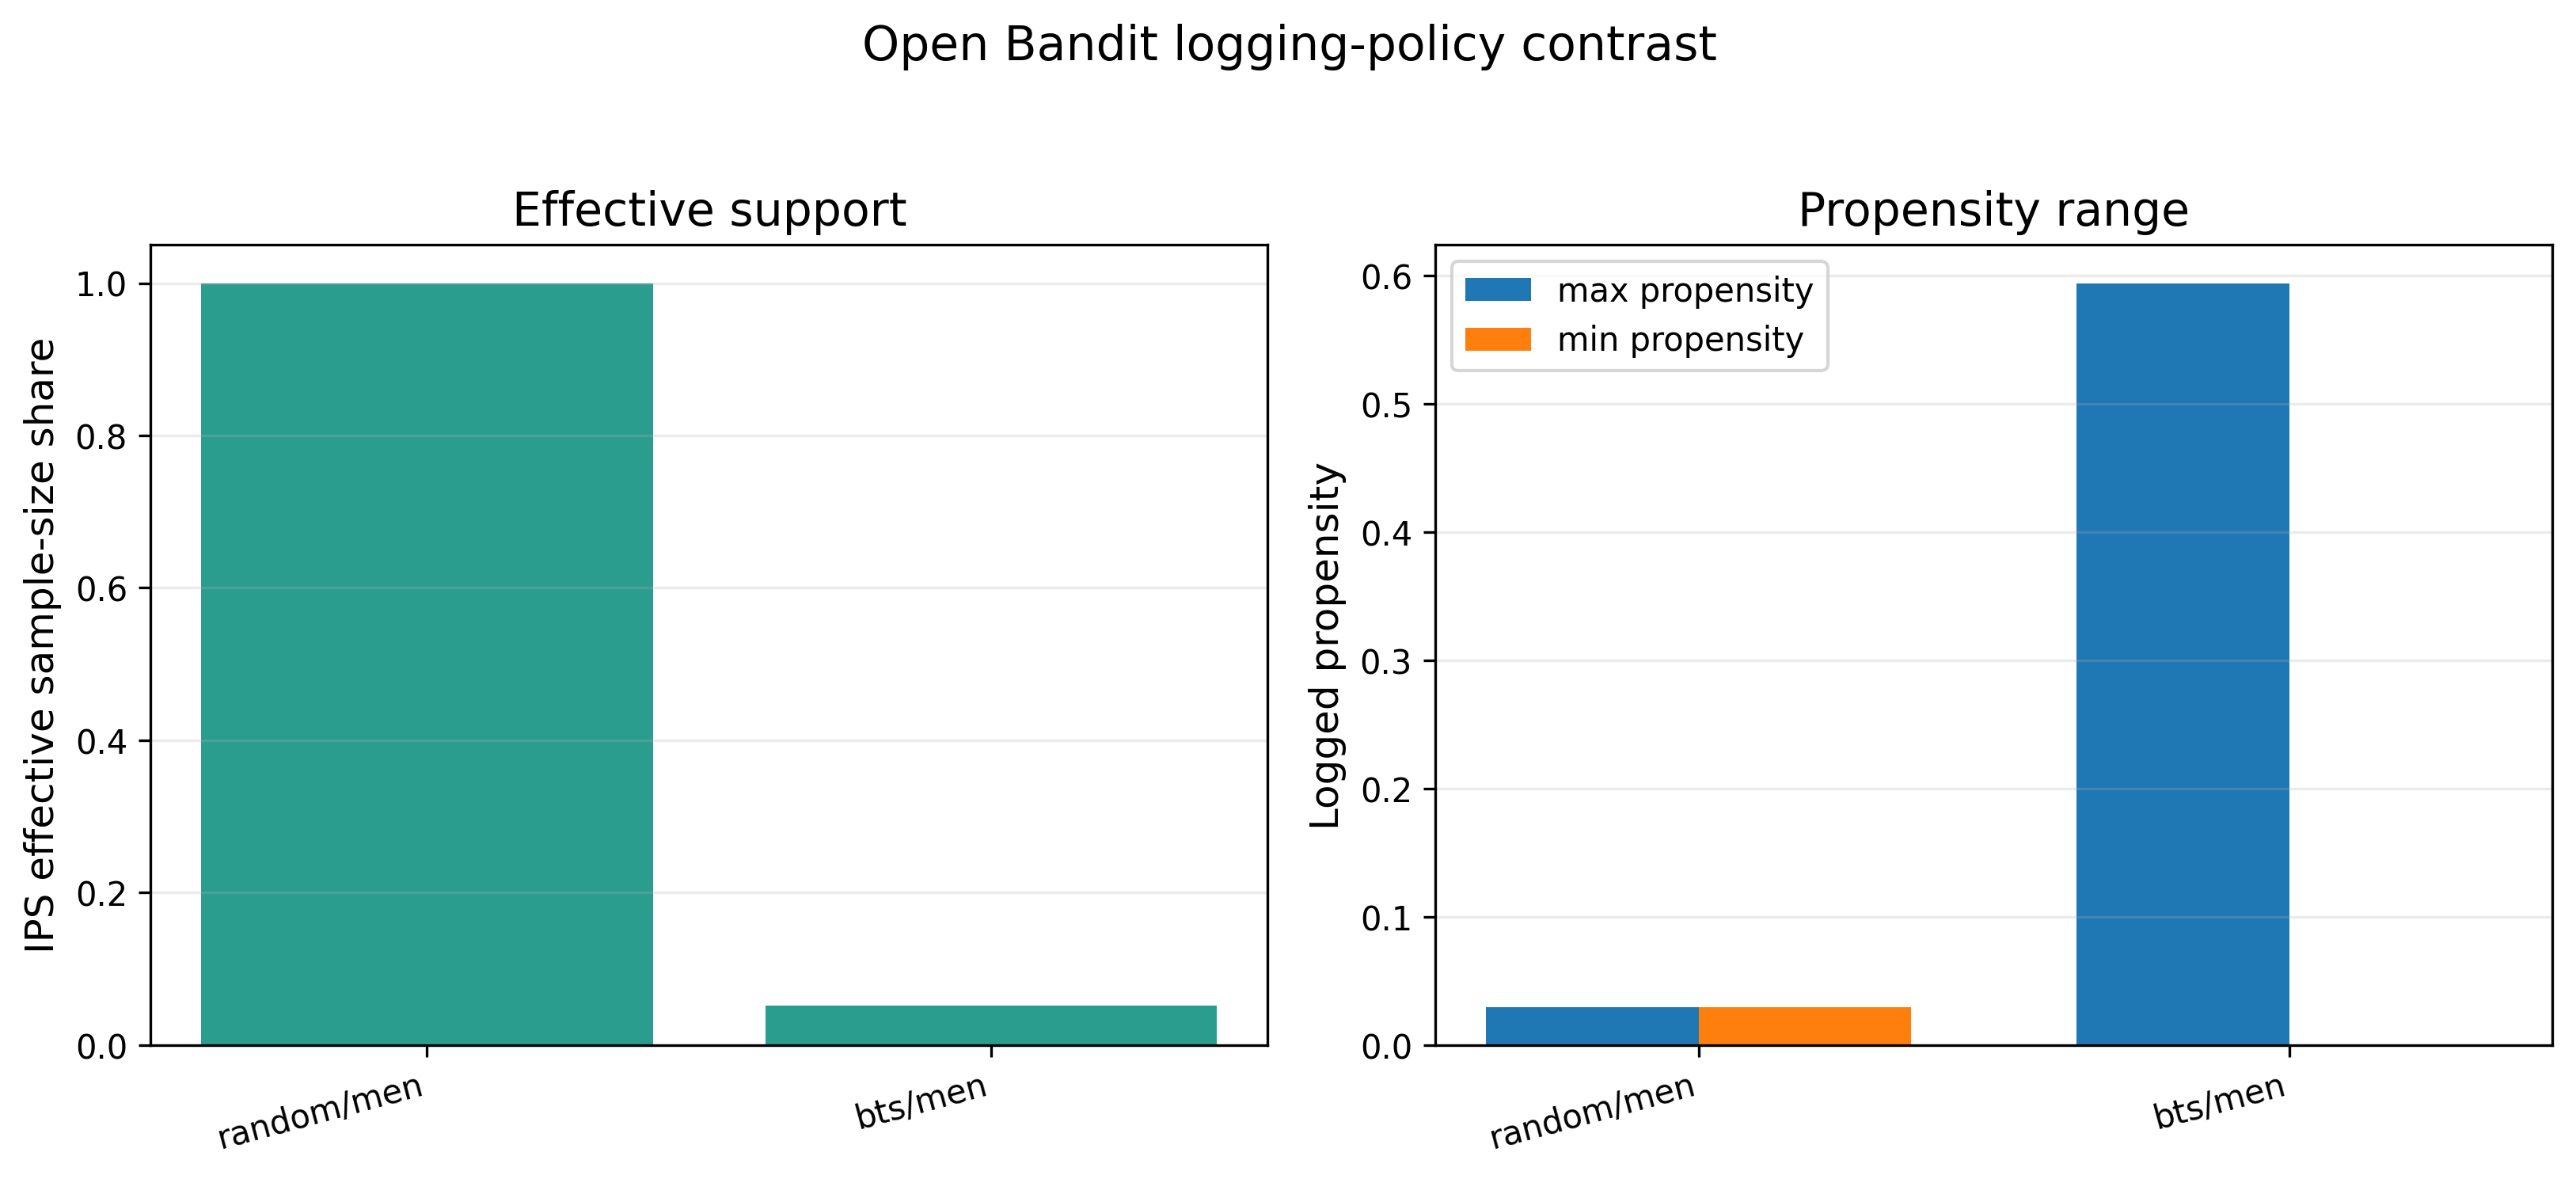

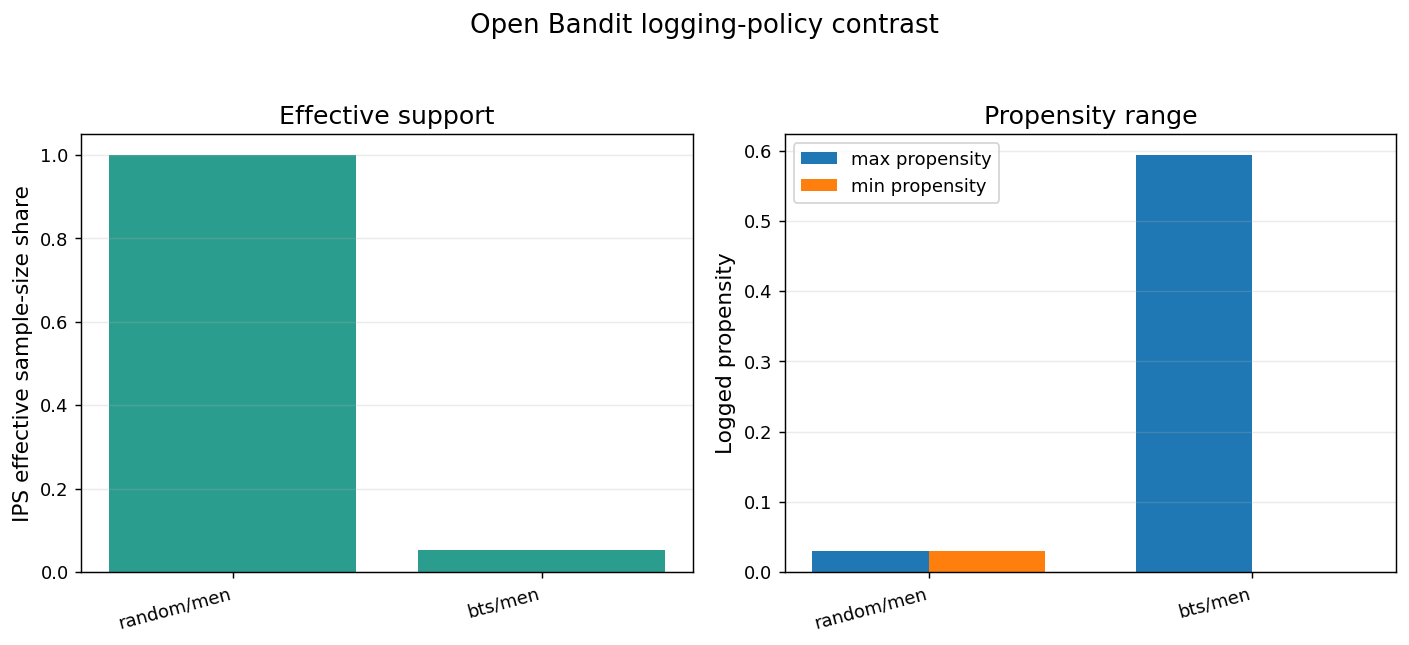

In [4]:
fig_path = paths.figure_dir / "03_open_bandit_propensity_comparison.png"
plot_open_bandit_propensity_comparison(calibration_table, propensity_diagnostics, fig_path)
display(Image(filename=str(fig_path)))


In [5]:
progress.log("Running recommendation design comparisons calibrated to both Open Bandit logging policies.")
ranked_cases = []
frontier_cases = []
shortlist_cases = []
for case in open_bandit_cases:
    key = f"{case['behavior_policy']}_{case['campaign']}"
    summary = run_open_bandit_known_propensity_case(samples[key], n_reps=120)
    ranked_case = design_recommendations(summary)
    ranked_case["behavior_policy"] = case["behavior_policy"]
    ranked_case["campaign"] = case["campaign"]
    ranked_case["open_bandit_slice"] = f"{case['behavior_policy']}/{case['campaign']}"

    frontier_case = pareto_frontier(ranked_case)
    shortlist_case = uncertainty_shortlist(ranked_case)

    ranked_cases.append(ranked_case)
    frontier_cases.append(frontier_case)
    shortlist_cases.append(shortlist_case)

ranked = pd.concat(ranked_cases, ignore_index=True)
frontier = pd.concat(frontier_cases, ignore_index=True)
shortlist = pd.concat(shortlist_cases, ignore_index=True)
write_table(ranked, paths.table_dir / "03_open_bandit_design_scores.csv")
write_table(frontier, paths.table_dir / "03_open_bandit_pareto_frontier.csv")
write_table(shortlist, paths.table_dir / "03_open_bandit_uncertainty_shortlist.csv")
ranked[["open_bandit_slice", "design", "design_risk", "exposure_distance", "assignment_unit_variance", "planning_mde", "contamination_risk", "operational_cost", "estimand_mismatch"]]


[04:20:39] 03-open-bandit: Running recommendation design comparisons calibrated to both Open Bandit logging policies.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/03_open_bandit_design_scores.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/03_open_bandit_pareto_frontier.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/03_open_bandit_uncertainty_shortlist.csv


,open_bandit_slice,design,design_risk,exposure_distance,assignment_unit_variance,planning_mde,contamination_risk,operational_cost,estimand_mismatch
0,random/men,switchback,2.182459,0.714409,0.000107,0.010908,0.012946,0.45,0.714409
1,random/men,cluster_randomization,2.244548,0.643129,0.000138,0.006211,0.458750,0.35,0.643129
2,random/men,two_stage_saturation,2.261018,0.517499,0.001365,0.005224,0.498764,0.80,0.517499
3,random/men,mixed_randomization,2.315623,0.523196,0.001400,0.005285,0.485110,0.90,0.523196
4,random/men,budget_split,2.390322,0.676265,0.000086,0.007849,0.295635,0.70,0.676265
5,random/men,user_randomization,3.313537,0.680206,0.013096,0.027547,0.214647,0.10,0.680206
6,bts/men,switchback,2.105236,0.714409,0.000133,0.012178,0.126384,0.45,0.771307
7,bts/men,cluster_randomization,2.297410,0.622953,0.000655,0.013480,0.662361,0.35,0.727265
8,bts/men,budget_split,2.476032,0.732378,0.000263,0.013662,0.323736,0.70,0.850914
9,bts/men,two_stage_saturation,2.730766,0.561760,0.005345,0.010412,0.757239,0.80,0.694521


[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/03_open_bandit_design_risk.png


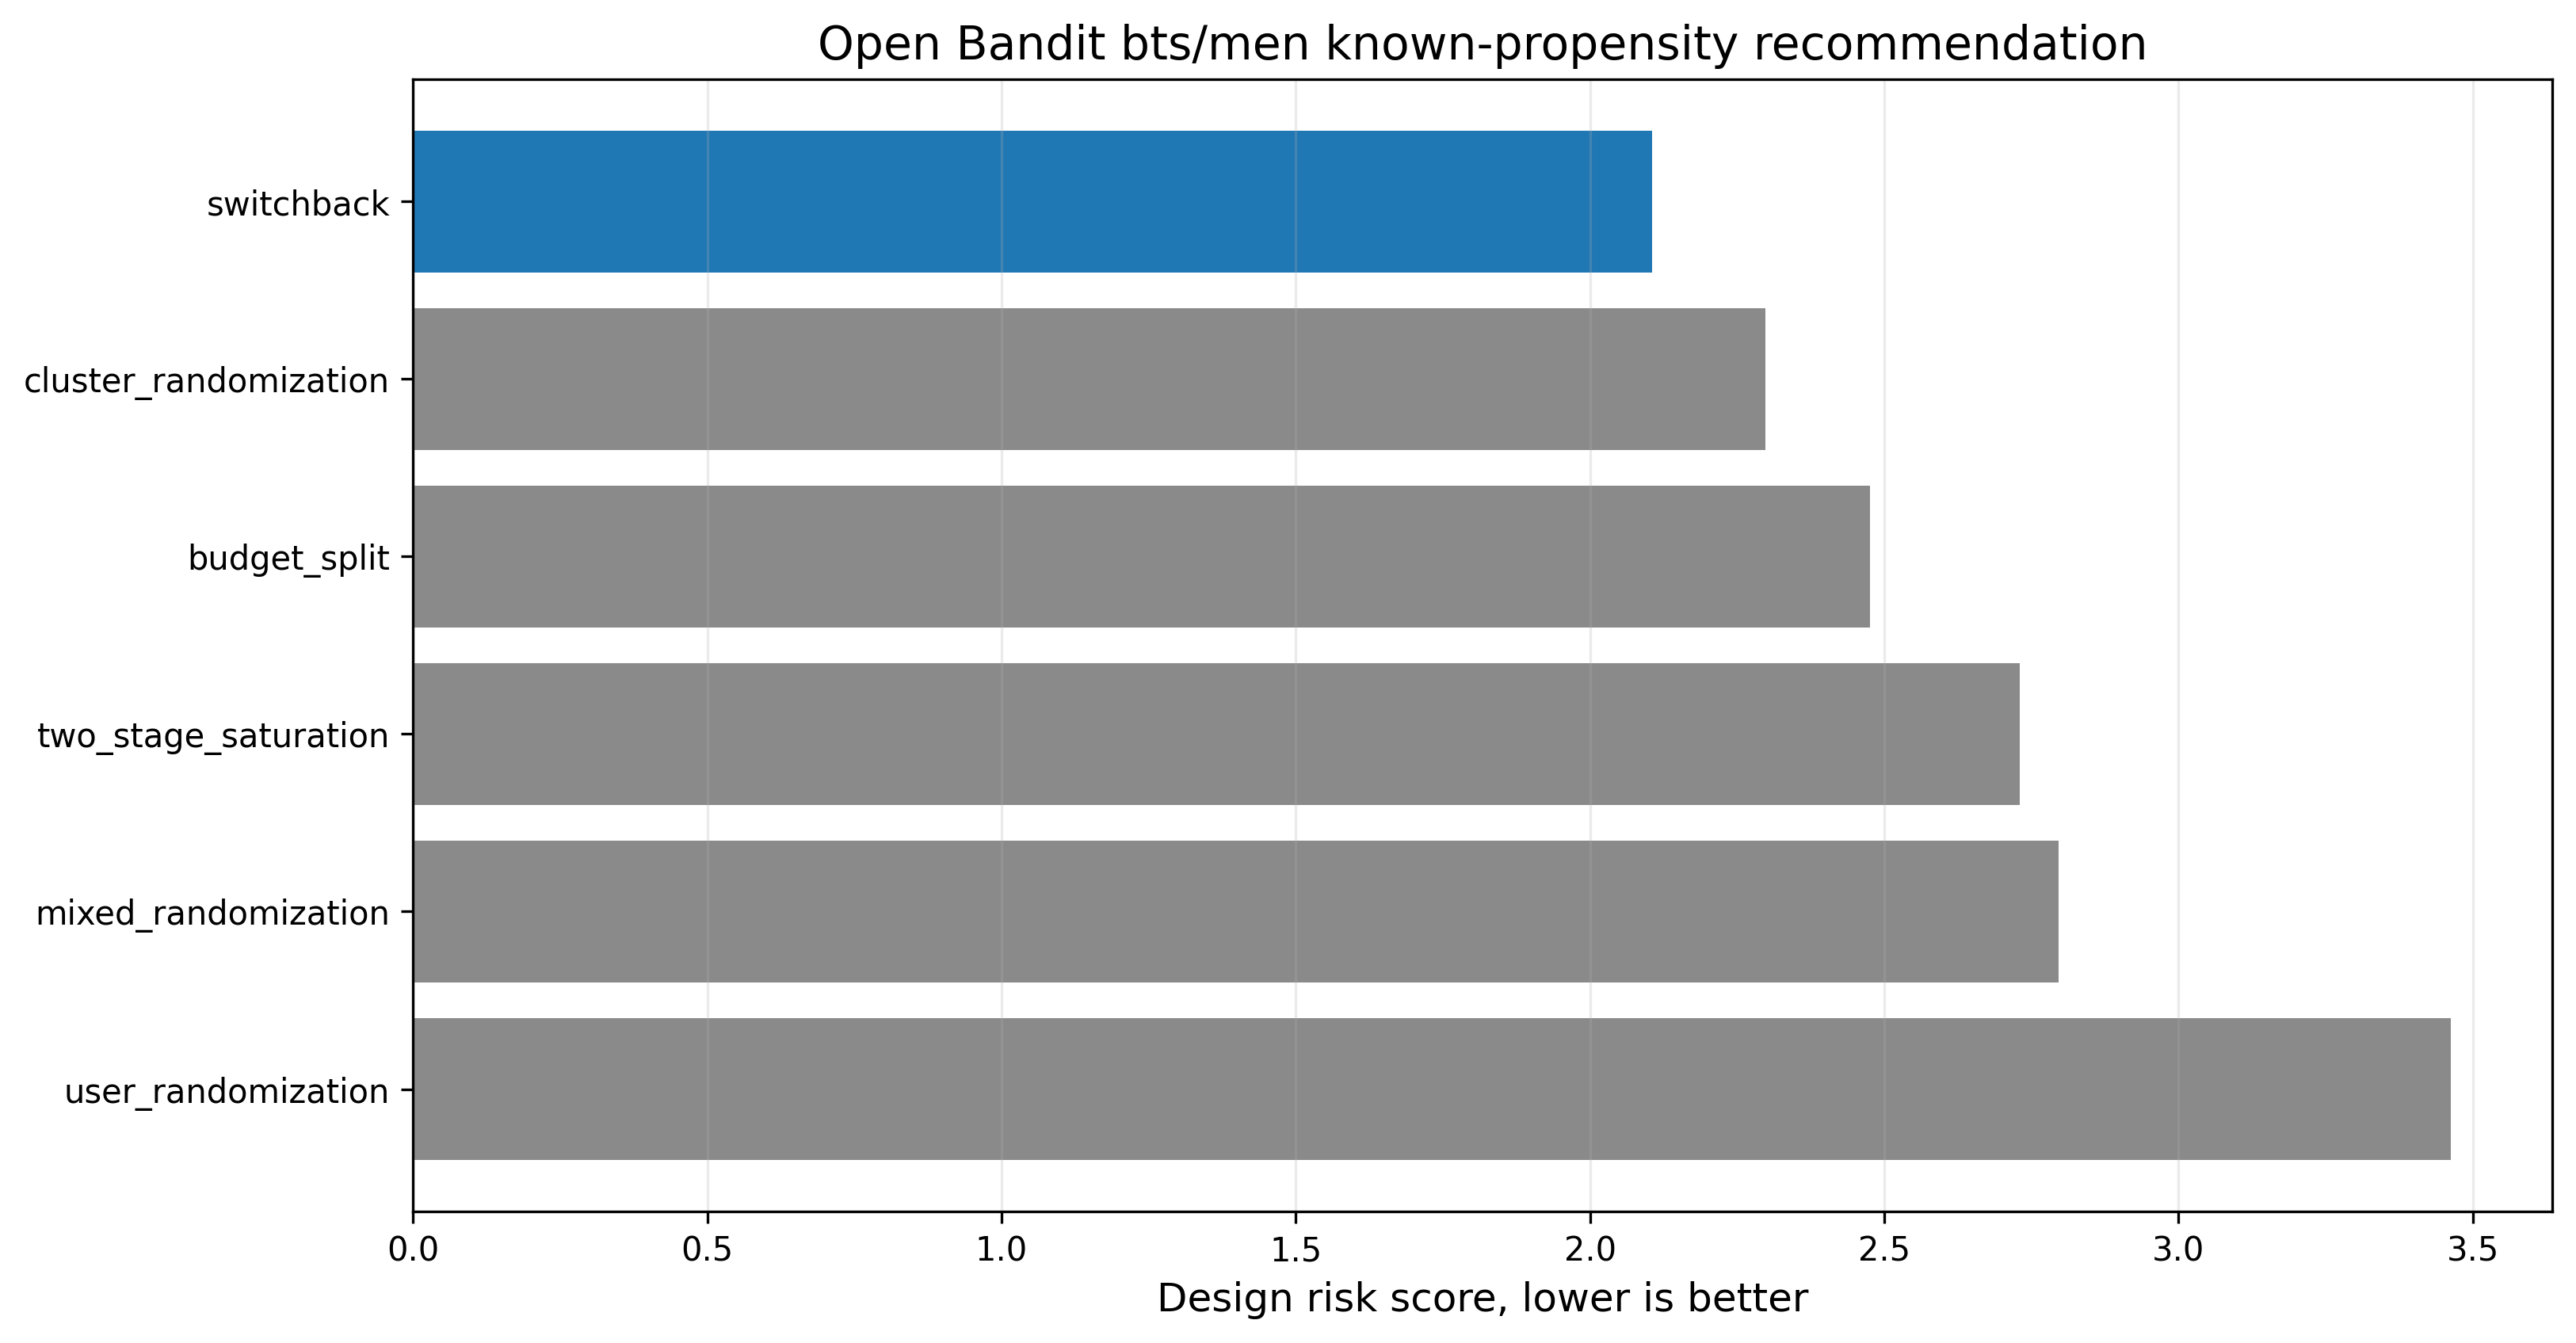

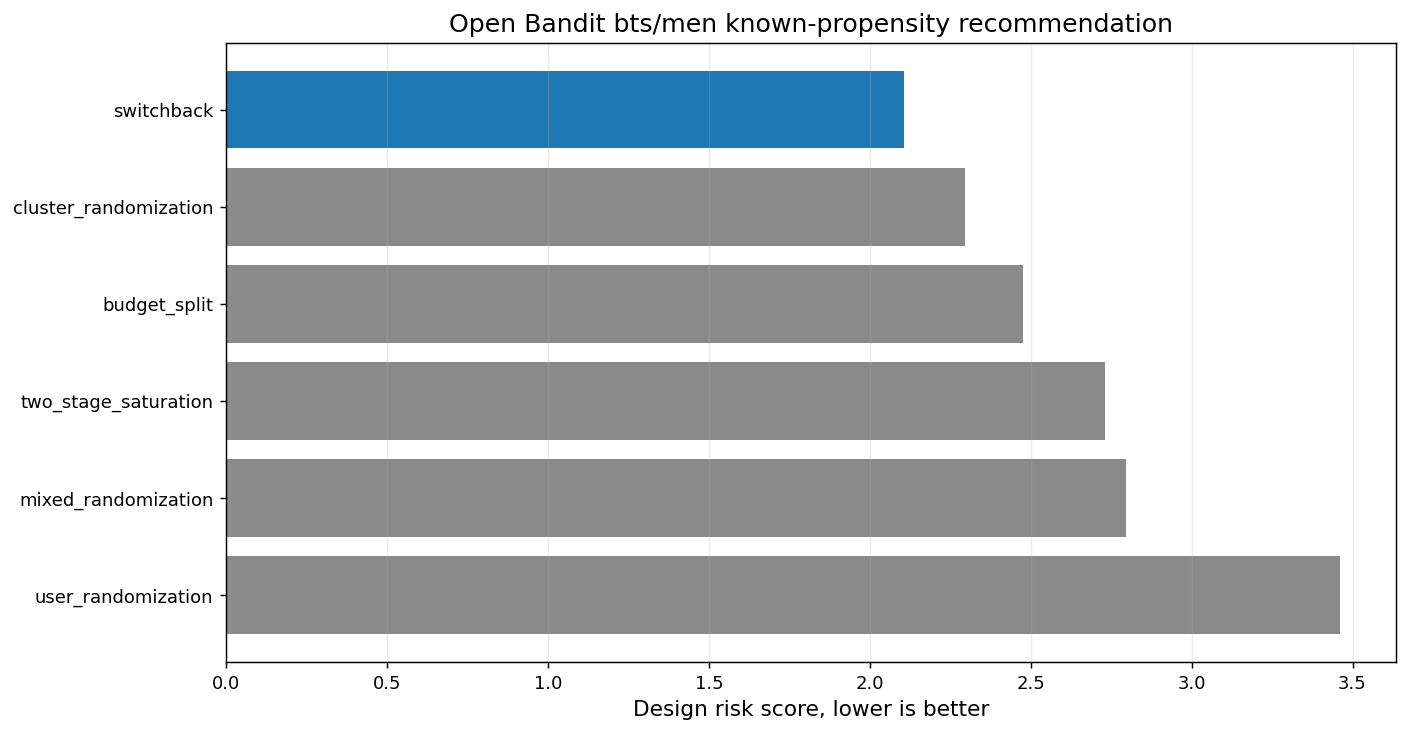

In [6]:
stress_ranked = ranked[ranked["open_bandit_slice"] == "bts/men"].copy()
fig_path = paths.figure_dir / "03_open_bandit_design_risk.png"
plot_design_risk(stress_ranked, "Open Bandit bts/men known-propensity recommendation", fig_path)
display(Image(filename=str(fig_path)))


[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/03_open_bandit_bias_variance_frontier.png


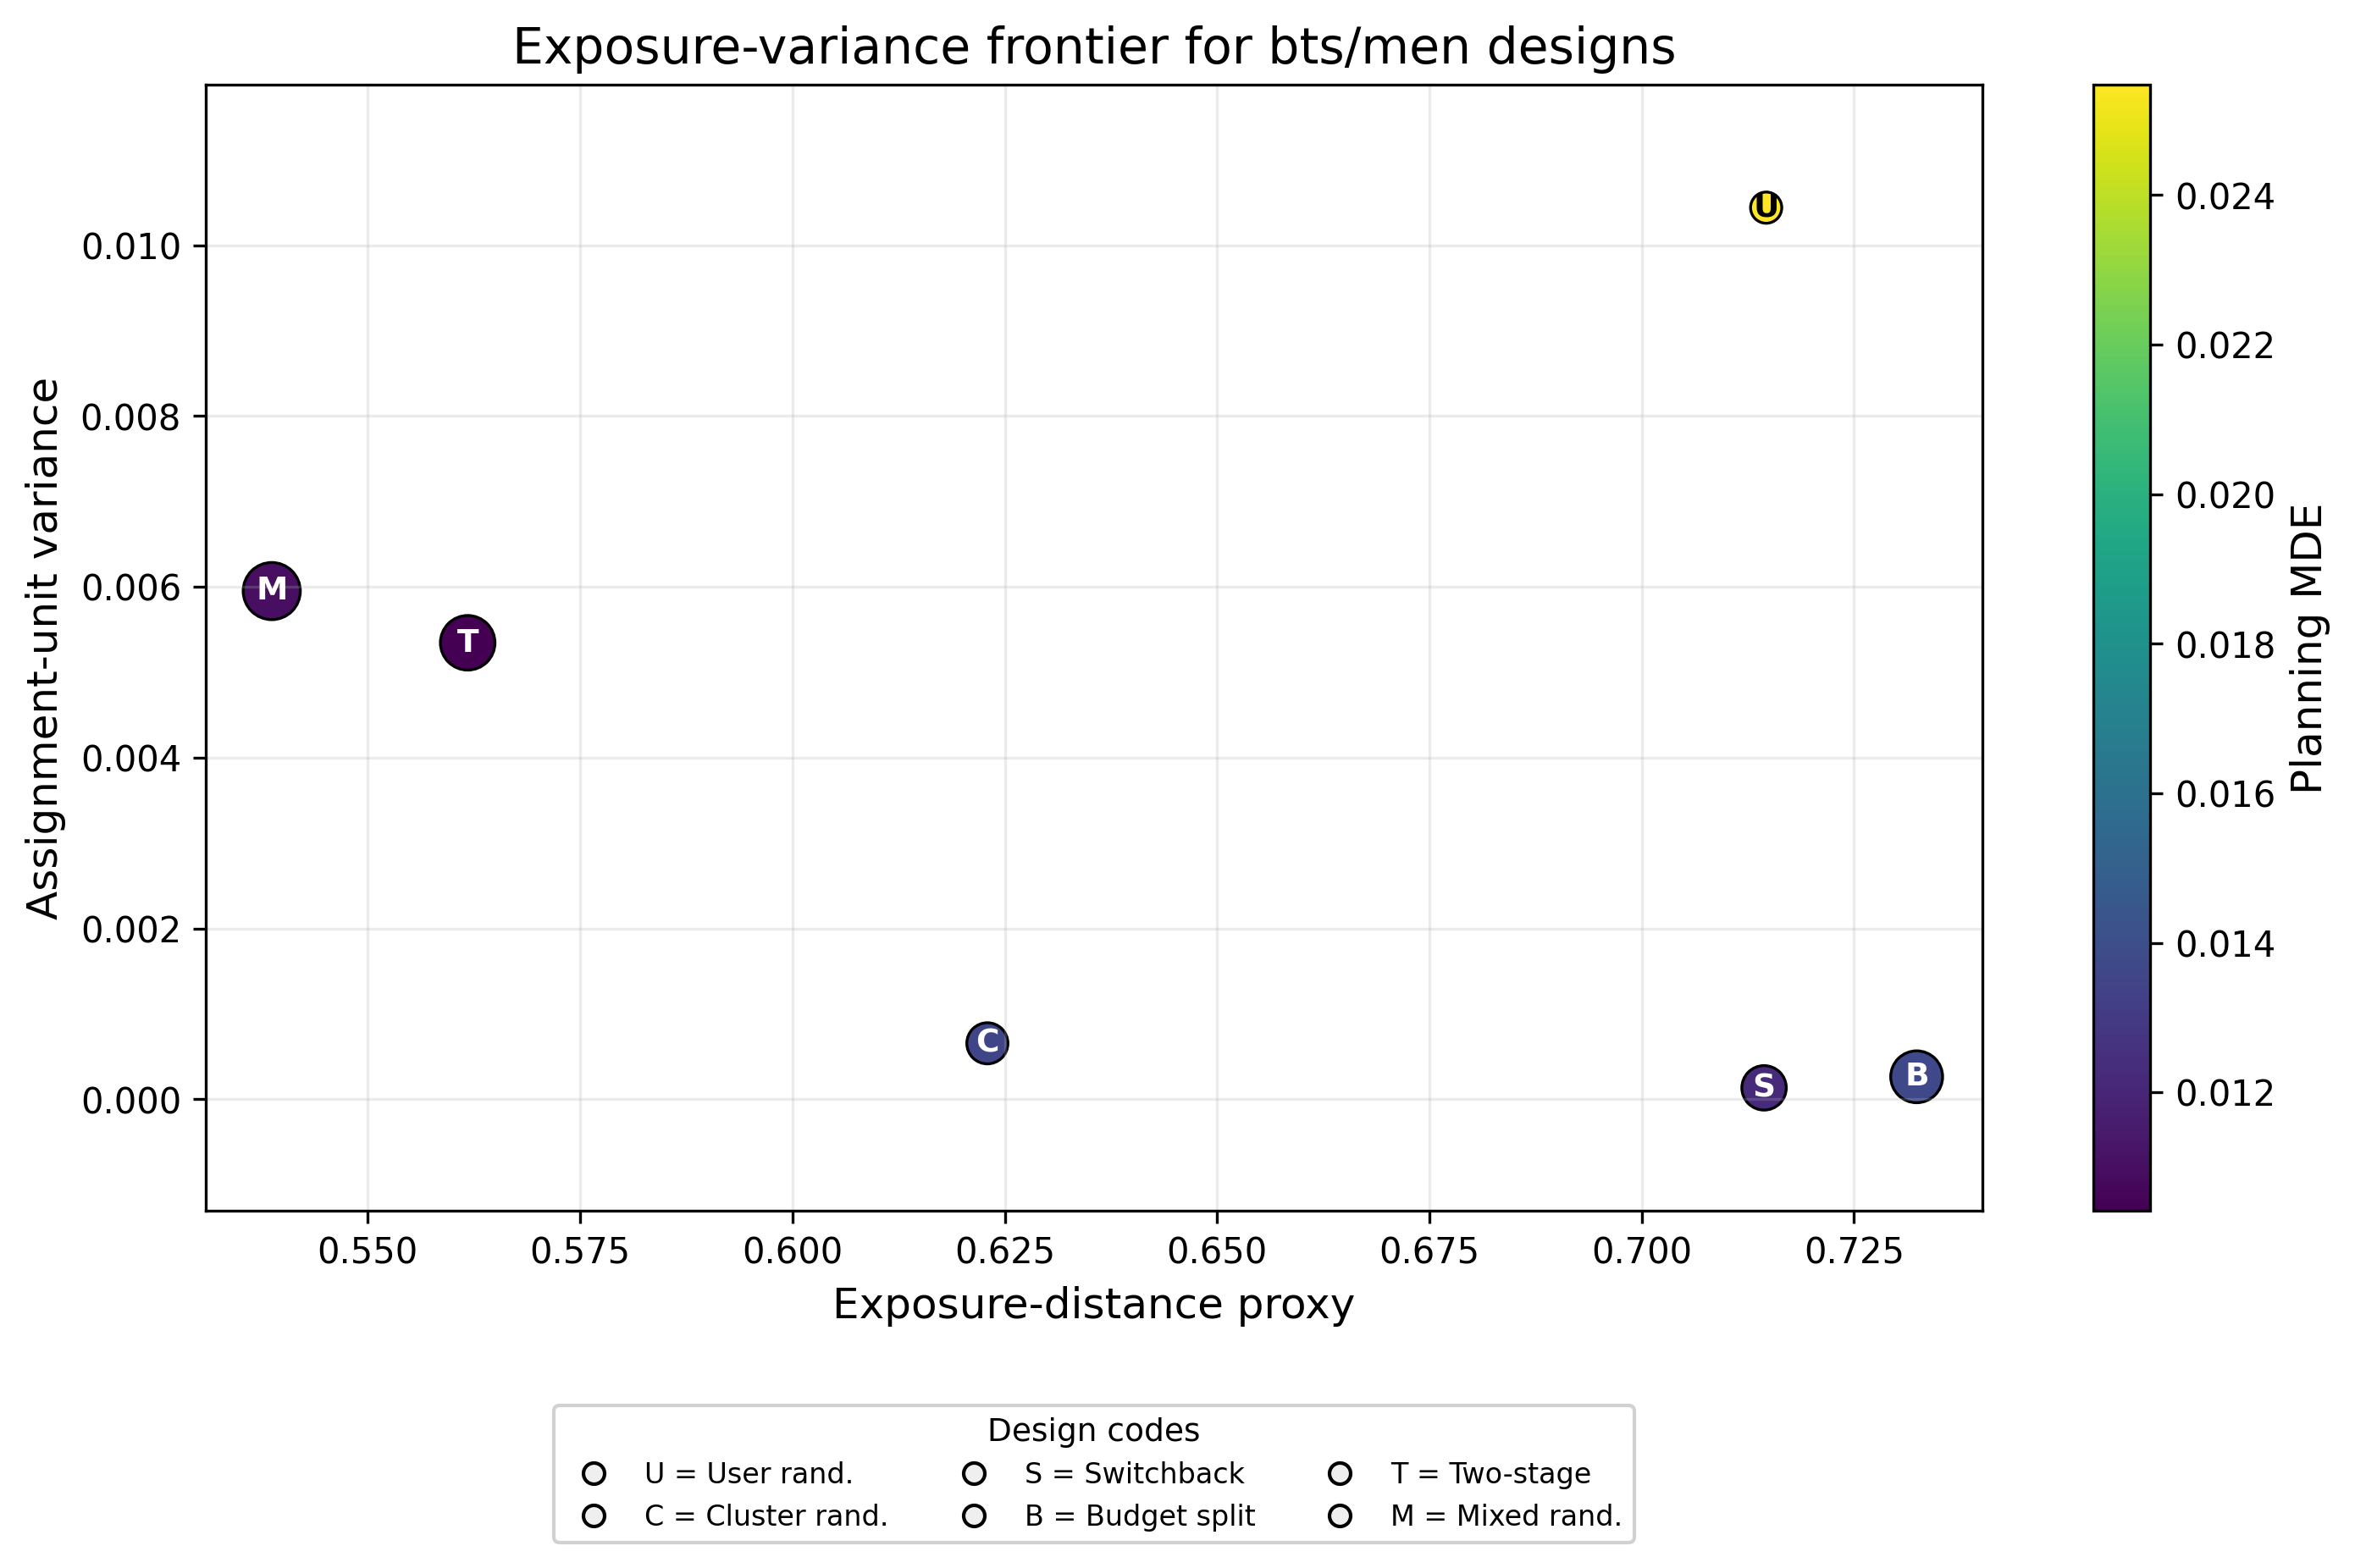

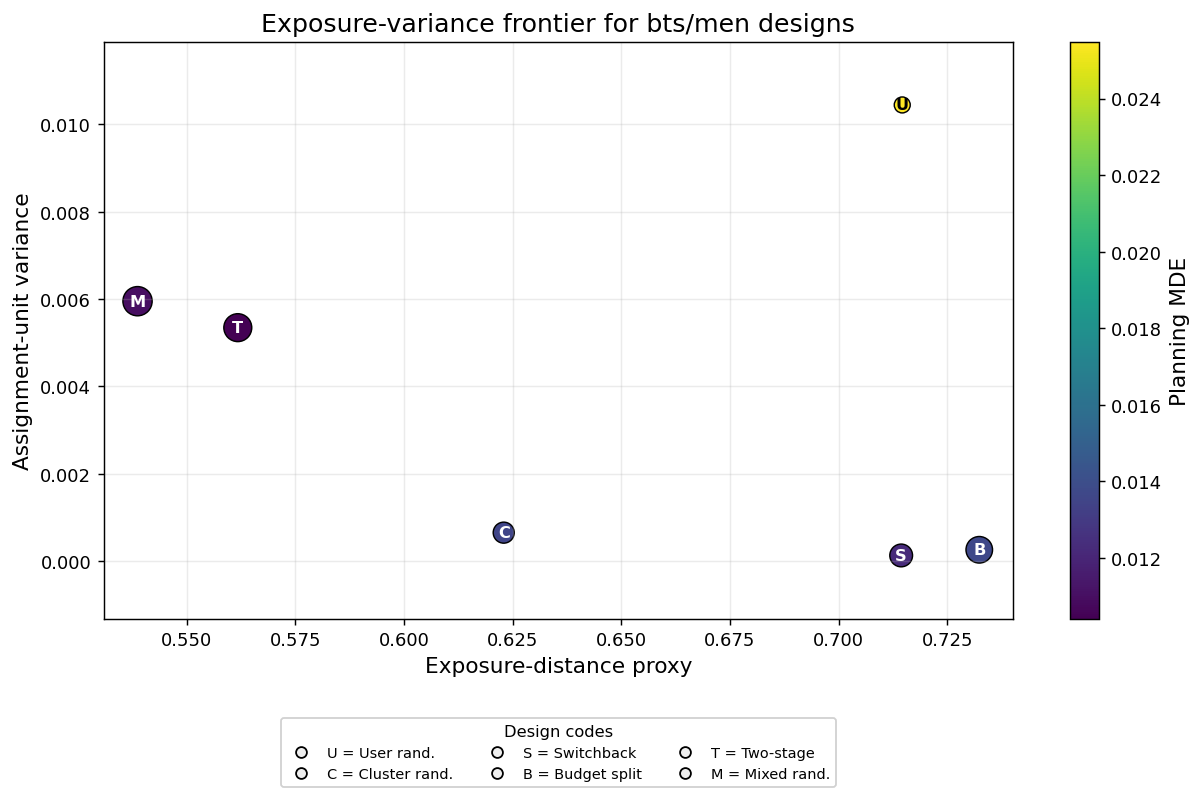

In [7]:
fig_path = paths.figure_dir / "03_open_bandit_bias_variance_frontier.png"
plot_bias_variance_frontier(stress_ranked, "Exposure-variance frontier for bts/men designs", fig_path)
display(Image(filename=str(fig_path)))
